<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/CO5420_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
import os
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path to your folder in MyDrive
# Replace 'YourFolderNameHere' with the exact name of your folder in MyDrive
folder_path = '/content/drive/MyDrive/co5420-autoencoder-for-image-denoising (1)'

# Optional: Verify that the path exists and check contents
if os.path.exists(folder_path):
    print("Folder found! Contents:", os.listdir(folder_path)[:5])
else:
    print("Folder path does not exist. Check the spelling or path.")

# 3. Apply standard data transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)), # Adjust size as needed
    transforms.ToTensor(),
])

# 4. Load dataset directly from folder
# Note: ImageFolder expects subfolders inside folder_path representing classes (e.g., folder_path/class_1/img.jpg)
# If your folder just contains raw images with no subfolders, use a custom Dataset class or standard image loading.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder found! Contents: ['test.csv', 'sample_submission.csv', 'train.csv', 'test_noisy', 'clean_train']


In [12]:
print(os.listdir('/content/drive/MyDrive'))

['WhatsApp Chat with G-Nisal 2003.txt', 'whatsbackup-2020829034205', 'whatsbackup-2020829034205 (Unzipped Files)', 'msgstore.db.crypt12', 'DriveSyncFiles', 'how to do this without using bubble just use norm....gsheet', 'University Course Registration UML Diagram.gsheet', 'Comprehensive Summary: Introduction to Application and Transport Layers.gdoc', 'Technical Report: Advanced Data Structures, Algorithmic Optimization, and Practical Implementations.gdoc', 'Google AI Studio', 'foodcart_database.drawio', 'entity_diagram.drawio', 'PHY - (විද්\u200dයුත් ක්ෂේත්\u200dර) Electric Fields.gdoc', 'cerebro_decoder_0342077a2a3329dfd2c0438093199ec9.c.gdoc', 'Colab Notebooks', 'Untitled Diagram.drawio', 'University Student Boarding Platform Needs Survey: MyStay Development.gform', 'MyStay App Feedback Form .gform', 'MyStay App Feedback Form  (Responses).gsheet', 'Technical Design Specification: 8-Bit Processor Core and Memory Subsystem.gdoc', 'co5420-autoencoder-for-image-denoising (1)']


###Import libraries and setup

In [8]:
# 1. IMPORT REQUIRED LIBRARIES


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split

# Progress bar
from tqdm.notebook import tqdm

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


###Define dataset path

In [14]:
# 2. DATASET PATH

DATA_PATH = "/content/drive/MyDrive/co5420-autoencoder-for-image-denoising (1)"

TRAIN_CSV = os.path.join(DATA_PATH, "train.csv")
TEST_CSV = os.path.join(DATA_PATH, "test.csv")

CLEAN_FOLDER = os.path.join(DATA_PATH, "clean_train")

print(os.listdir(DATA_PATH))

['test.csv', 'sample_submission.csv', 'train.csv', 'test_noisy', 'clean_train']


###Load training CSV

In [15]:
# 3. LOAD TRAIN DATA

train_df = pd.read_csv(TRAIN_CSV)

print(train_df.head())

print("Shape:", train_df.shape)

   id  pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0   0        0        0        0        0        0        0        0        0   
1   1        0        0        0        0        0        1        0        0   
2   2        0        0        0        0        0        0        0        0   
3   3        0        0        0        0        0        0        0        0   
4   4        0        0        0        0        0        0        0        0   

   pixel_8  ...  pixel_774  pixel_775  pixel_776  pixel_777  pixel_778  \
0        0  ...          0          0          0          0          0   
1        0  ...        119        114        130         76          0   
2        0  ...          0          0          1          0          0   
3       33  ...          0          0          0          0          0   
4        0  ...          0          0          0          0          0   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  
0        

###Convert pixels into images


In [16]:
# 4. CONVERT CSV PIXELS TO IMAGES


# Remove ID column
images = train_df.drop("id", axis=1).values


# Convert:
# 60000 x 784
#
# into:
# 60000 x 1 x 28 x 28

images = images.reshape(-1,1,28,28)


print(images.shape)

(60000, 1, 28, 28)


###Normalize pixels

In [17]:
# 5. NORMALIZATION

images = images.astype("float32") / 255.0

print(images.min())
print(images.max())

0.0
1.0


###Visualize clean images

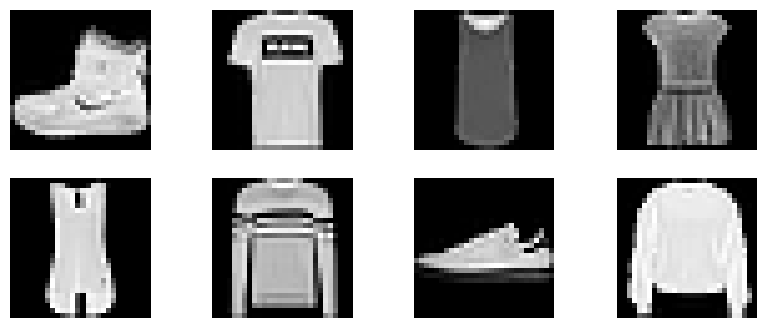

In [18]:
# 6. DISPLAY SAMPLE IMAGES


plt.figure(figsize=(10,4))


for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i][0], cmap="gray")

    plt.axis("off")


plt.show()

###Create noise functions

Gaussian Noise

In [19]:
# 7. GAUSSIAN NOISE

def add_gaussian_noise(img):

    sigma = np.random.uniform(0.05,0.30)

    noise = np.random.normal(
        0,
        sigma,
        img.shape
    )

    noisy = img + noise

    return np.clip(noisy,0,1)

Salt and Pepper Noise

In [20]:
# SALT AND PEPPER NOISE


def add_salt_pepper_noise(img):

    amount = np.random.uniform(0.02,0.15)


    noisy = img.copy()


    # number of corrupted pixels

    num_pixels = int(amount * img.size)


    # Salt (white)

    coords = np.random.randint(
        0,
        img.size,
        num_pixels//2
    )

    noisy.reshape(-1)[coords] = 1



    # Pepper (black)

    coords = np.random.randint(
        0,
        img.size,
        num_pixels//2
    )

    noisy.reshape(-1)[coords] = 0


    return noisy

Poisson Noise

In [21]:
def add_poisson_noise(img):

    vals = len(np.unique(img))

    vals = 2 ** np.ceil(np.log2(vals))

    noisy = np.random.poisson(img * vals) / float(vals)

    return np.clip(noisy,0,1)

Speckle Noise

In [22]:
def add_speckle_noise(img):

    noise = np.random.randn(*img.shape)

    noisy = img + img * noise * 0.20

    return np.clip(noisy,0,1)

###Test the noise

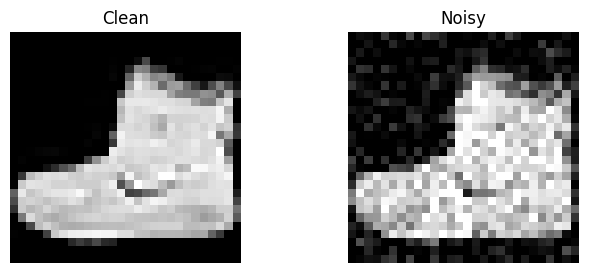

In [23]:
# ==========================================
# 8. VISUALIZE NOISE
# ==========================================


clean = images[0]


noisy = add_gaussian_noise(clean)


plt.figure(figsize=(8,3))


plt.subplot(1,2,1)
plt.title("Clean")
plt.imshow(clean[0], cmap="gray")
plt.axis("off")


plt.subplot(1,2,2)
plt.title("Noisy")
plt.imshow(noisy[0], cmap="gray")
plt.axis("off")


plt.show()

###Create PyTorch Dataset

In [24]:
# ==========================================
# 9. CUSTOM DATASET
# ==========================================

class DenoisingDataset(Dataset):

    def __init__(self, images):

        self.images = images


    def __len__(self):

        return len(self.images)



    def __getitem__(self,index):

        clean = self.images[index]

        noise_choice = np.random.randint(4)

        if noise_choice == 0:
            noisy = add_gaussian_noise(clean)

        elif noise_choice == 1:
            noisy = add_salt_pepper_noise(clean)

        elif noise_choice == 2:
            noisy = add_poisson_noise(clean)

        else:
            noisy = add_speckle_noise(clean)

        return (
            torch.tensor(noisy),
            torch.tensor(clean)
    )

###Create DataLoaders

In [25]:
# 10. DATALOADERS


dataset = DenoisingDataset(images)


train_size = int(0.9*len(dataset))

val_size = len(dataset)-train_size


train_dataset, val_dataset = random_split(
    dataset,
    [train_size,val_size]
)


train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)


print(len(train_dataset))
print(len(val_dataset))

54000
6000


###Build Convolutional Autoencoder

In [26]:
# 11. U-NET FOR IMAGE DENOISING

import torch
import torch.nn as nn



# Double Convolution Block


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)



# U-Net

class Autoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.down1 = DoubleConv(1,32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32,64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64,128)

        # Decoder

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.conv2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.conv1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )


    def forward(self,x):

        # Encoder

        x1 = self.down1(x)

        x2 = self.pool1(x1)

        x3 = self.down2(x2)

        x4 = self.pool2(x3)

        x5 = self.bridge(x4)

        # Decoder

        x = self.up2(x5)

        x = torch.cat([x,x3],dim=1)

        x = self.conv2(x)

        x = self.up1(x)

        x = torch.cat([x,x1],dim=1)

        x = self.conv1(x)

        x = self.final(x)

        return torch.sigmoid(x)

###Create model

In [27]:
# 12. INITIALIZE MODEL



model = Autoencoder().to(device)


criterion = nn.MSELoss()


optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

print(model)

Autoencoder(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )


###Training Loop

In [28]:
# 13. TRAINING LOOP


NUM_EPOCHS = 50

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    # ----------------------------
    # Training
    # ----------------------------
    model.train()

    running_loss = 0

    progress = tqdm(train_loader)

    for noisy, clean in progress:

        noisy = noisy.float().to(device)
        clean = clean.float().to(device)

        optimizer.zero_grad()

        output = model(noisy)

        loss = criterion(output, clean)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_description(
            f"Epoch [{epoch+1}/{NUM_EPOCHS}]"
        )

        progress.set_postfix(
            loss=loss.item()
        )

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # ----------------------------
    # Validation
    # ----------------------------

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for noisy, clean in val_loader:

            noisy = noisy.float().to(device)
            clean = clean.float().to(device)

            output = model(noisy)

            loss = criterion(output, clean)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    scheduler.step()
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss = {train_loss:.6f} | "
        f"Validation Loss = {val_loss:.6f}"
    )

    # ----------------------------
    # Save Best Model
    # ----------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "val_loss": val_loss
            },
            "best_unet.pth"
        )
        print("Best model saved.")

  0%|          | 0/211 [00:00<?, ?it/s]

Epoch 1 | Train Loss = 0.009708 | Validation Loss = 0.003857
Best model saved.


  0%|          | 0/211 [00:00<?, ?it/s]

Epoch 2 | Train Loss = 0.003454 | Validation Loss = 0.003056
Best model saved.


  0%|          | 0/211 [00:00<?, ?it/s]

...

Epoch 48 | Train Loss = 0.001608 | Validation Loss = 0.001556


  0%|          | 0/211 [00:00<?, ?it/s]

Epoch 49 | Train Loss = 0.001607 | Validation Loss = 0.001554


  0%|          | 0/211 [00:00<?, ?it/s]

Epoch 50 | Train Loss = 0.001609 | Validation Loss = 0.001573


###Plot Training Curves

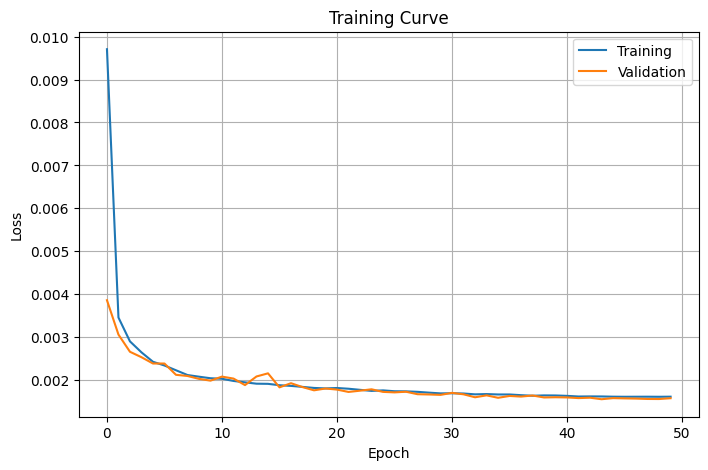

In [29]:
# ==========================================
# 14. TRAINING CURVES
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Training")

plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Curve")

plt.legend()

plt.grid(True)

plt.show()

###Load Best Model

In [30]:
# ==========================================
# 15. LOAD BEST MODEL
# ==========================================

checkpoint = torch.load("best_unet.pth")

model.load_state_dict(
    checkpoint["model"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)
model.eval()

print("Best model loaded.")

Best validation loss: 0.0015496435905030619
Best model loaded.


###Visualise Denoising Results

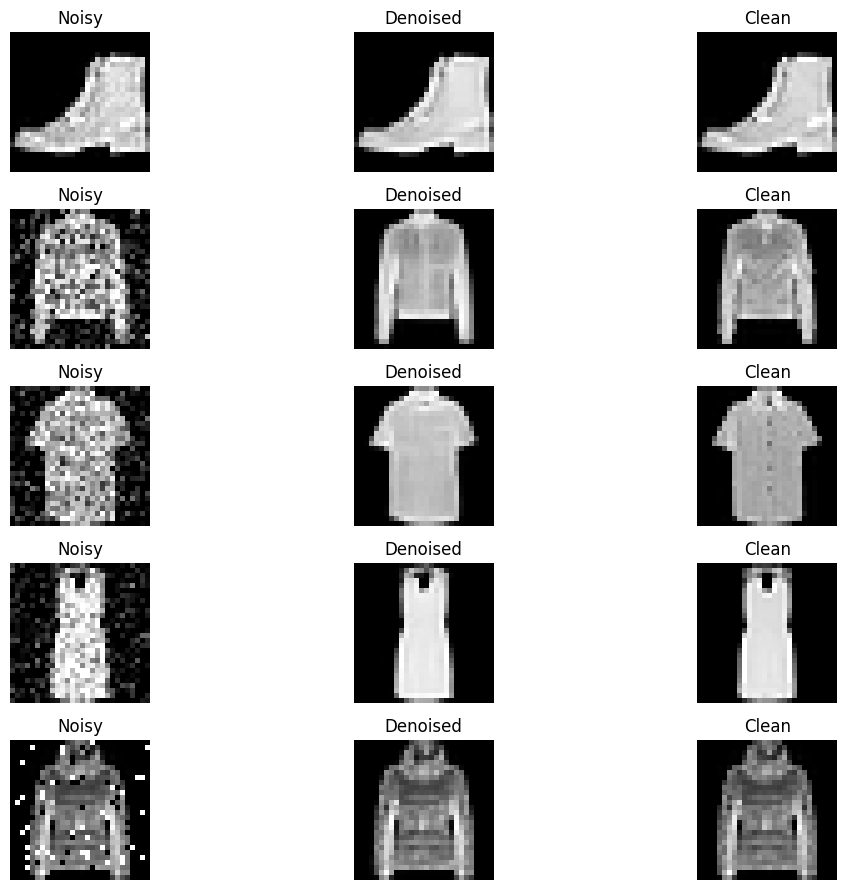

In [31]:
# ==========================================
# 16. VISUALIZE DENOISING RESULTS
# ==========================================

model.eval()

noisy, clean = next(iter(val_loader))

noisy = noisy.float().to(device)

with torch.no_grad():

    output = model(noisy)

output = output.cpu().numpy()
noisy = noisy.cpu().numpy()
clean = clean.numpy()

plt.figure(figsize=(12,9))

for i in range(5):

    # Noisy
    plt.subplot(5,3,3*i+1)
    plt.imshow(noisy[i][0],cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Output
    plt.subplot(5,3,3*i+2)
    plt.imshow(output[i][0],cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # Target
    plt.subplot(5,3,3*i+3)
    plt.imshow(clean[i][0],cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()

plt.show()

###Read Kaggle Test Data

In [32]:
# ==========================================
# 17. LOAD TEST DATA
# ==========================================

test_df = pd.read_csv(TEST_CSV)

print(test_df.shape)

test_ids = test_df["id"]

test_images = test_df.drop("id",axis=1).values

test_images = test_images.reshape(-1,1,28,28)

test_images = test_images.astype(np.float32)/255.0

(10000, 785)


###Predict Clean Images

In [33]:
# ==========================================
# 18. PREDICT TEST IMAGES
# ==========================================

model.eval()

predictions = []

with torch.no_grad():

    for img in tqdm(test_images):

        img = torch.tensor(img).unsqueeze(0).float().to(device)

        output = model(img)

        output = output.squeeze().cpu().numpy()

        output = np.clip(output,0,1)

        predictions.append(output.flatten())

predictions = np.array(predictions)

print(predictions.shape)

  0%|          | 0/10000 [00:00<?, ?it/s]

(10000, 784)


###Convert Back to Pixel Values

In [34]:

# 19. CONVERT TO 0-255


predictions = predictions * 255

predictions = np.clip(predictions,0,255)

predictions = predictions.astype(np.float32)

###Create Submission CSV

In [35]:

# 20. CREATE SUBMISSION FILE


submission = pd.DataFrame(
    predictions,
    columns=[f"pixel_{i}" for i in range(784)]
)

submission.insert(0,"id",test_ids)

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully.")

submission.head()

submission.csv created successfully.


,id,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0.674738,0.232649,0.295209,0.507740,0.309420,0.650259,0.413365,0.466241,0.345640,...,0.315592,0.188441,0.153573,0.142066,0.127011,0.111333,0.124824,0.148892,0.168570,0.286448
1,1,0.529597,0.141362,0.102414,0.111464,0.051296,0.046107,0.030061,0.058003,0.123102,...,0.251477,0.620625,0.322013,1.857036,166.893280,192.011276,65.825195,0.247474,0.423452,0.451122
2,2,0.468276,0.098179,0.145521,0.313523,0.319250,0.236373,0.159842,0.191872,0.312789,...,152.838135,37.659988,0.155004,0.208547,0.490428,0.403193,0.458353,0.224178,0.200667,0.208414
3,3,0.490799,0.091070,0.116244,0.208950,0.229233,0.286995,0.399043,0.815537,0.414579,...,4.745776,0.228078,0.700578,0.399387,0.306251,0.249702,0.213365,0.080588,0.104431,0.176715
4,4,0.400254,0.161636,0.233770,0.383709,0.329993,0.237416,0.188225,0.125630,0.137859,...,68.393776,9.340110,1.030202,0.659531,0.890236,0.625213,0.413652,0.268831,0.360257,0.550634


###Download the CSV

In [ ]:
# ==========================================
# 21. DOWNLOAD SUBMISSION
# ==========================================

from google.colab import files

files.download("submission.csv")